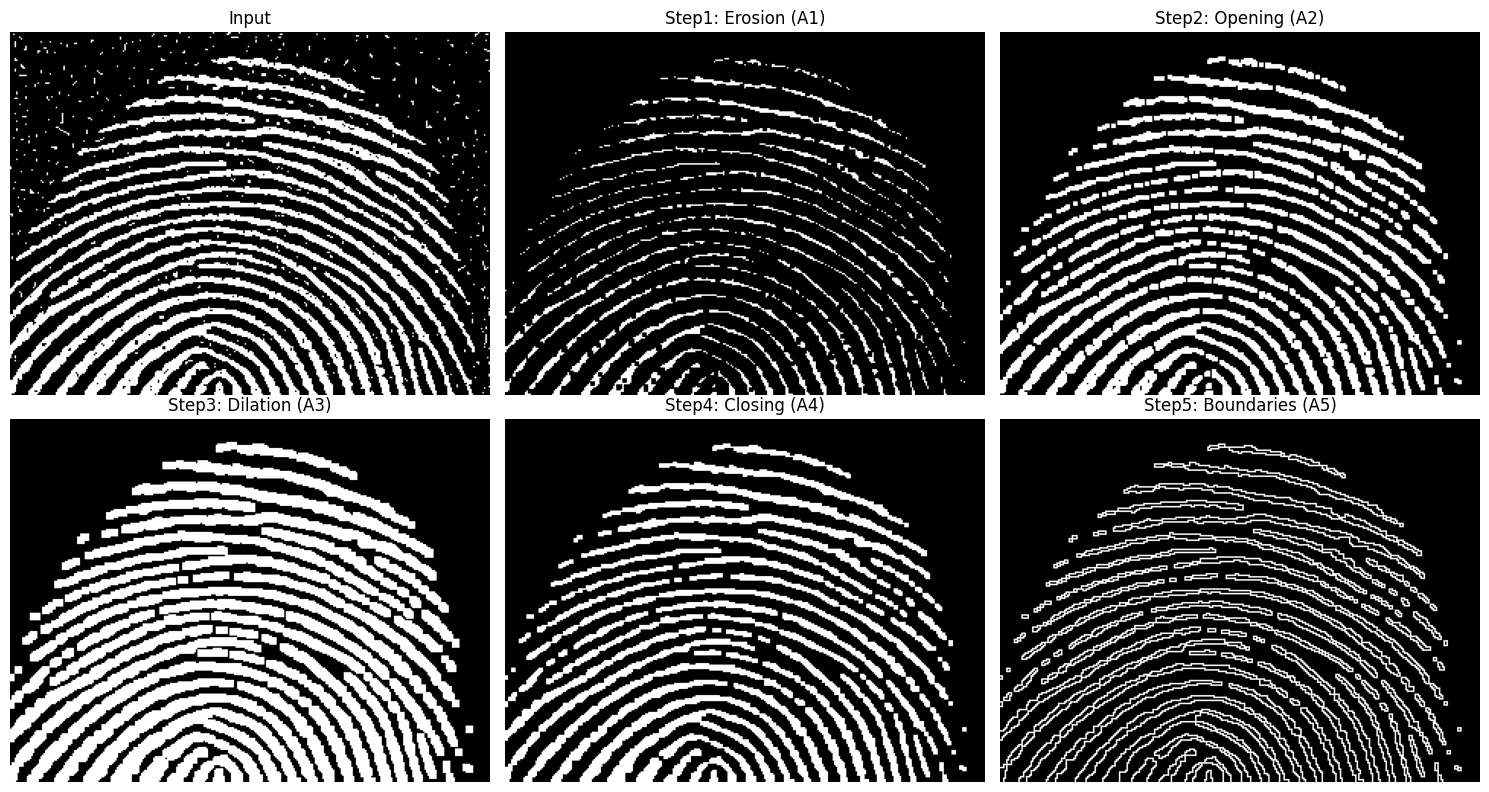

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
filter=np.ones((3,3),dtype=np.uint8)
def erosion(img):
    h, w = img.shape
    padded = np.pad(img, 1, mode='edge')
    out = np.zeros_like(img)
    for i in range(h):
        for j in range(w):
              region = padded[i:i+3, j:j+3]
              ok = 1
              for ii in range(3):
                for jj in range(3):
                    if(region[ii,jj]!=filter[ii,jj]):
                        ok=0
                        break
              if ok:
                out[i, j] = 1 
    return out
def dilation(img):
    h, w = img.shape
    padded = np.pad(img, 1, mode='edge')
    out = np.zeros_like(img)
    for i in range(h):
        for j in range(w):
              region = padded[i:i+3, j:j+3]
              for ii in range(3):
                for jj in range(3):
                    if(region[ii,jj]==filter[ii,jj]):
                        out[i, j] = 1
                        break
             
    return out
pil_img = Image.open('images/finger.tif').convert('1')
A = np.array(pil_img, dtype=np.uint8)

A1 = erosion(A)                 
A2 = dilation(A1)               
A3 = dilation(A2)               
A4 = erosion(A3)                
A4_eroded = erosion(A4)         
A5 = A4 - A4_eroded             

titles = ['Input', 'Step1: Erosion (A1)', 'Step2: Opening (A2)',
          'Step3: Dilation (A3)', 'Step4: Closing (A4)', 'Step5: Boundaries (A5)']
images = [A, A1, A2, A3, A4, A5]

plt.figure(figsize=(15, 8))
for i in range(len(titles)):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.tight_layout()
plt.show()